In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [ ]:
df = pd.read_csv('/content/cgpa.txt')

In [ ]:
df.head()

,CGPA,IQ,Placed
0,8.5,120,1
1,7.2,110,1
2,6.8,105,0
3,9.1,130,1
4,5.9,95,0


In [ ]:
p = Perceptron()
X = df.drop(columns='Placed')
y = df['Placed']
X_train,X_test,y_train,y_test = train_test_split(X,y)
p.fit(X_train,y_train)

Perceptron()

In [ ]:
accuracy_score(y_test,p.predict(X_test))

0.5

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(


<Axes: >

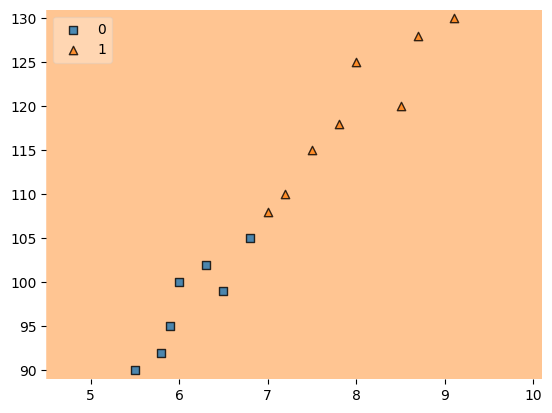

In [ ]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X.values,y.values,clf=p,legend=2)

# Perceptron from Scratch

In [ ]:
class my_Perceptron:
  def __init__(self,epochs=1000,learning_rate=0.1):
    self.epochs = epochs
    self.lr = learning_rate
    self.coef = None


  def fit(self,X_train,y_train):
    X_train = X_train.values
    y_train = y_train.values
    X_train = np.insert(X_train,0,1,axis=1)
    weights = np.zeros(X_train.shape[1])


    for i in range(self.epochs):
      # j = np.random.randint(0,X_train.shape[0])
      for j in range(X_train.shape[0]):
        pred = np.dot(weights,(X_train[j]))
        if y_train[j] == 0 and pred >0:
          weights = weights - (self.lr*X_train[j])
        elif y_train[j] ==1  and pred <0:
          weights = weights + (self.lr*X_train[j])
    self.coef = weights

  def predict(self,X_test):
    # print(self.coef[:,1:].shape,X_test.T.shape)
    # print(self.coef[0])
    X_test = X_test.values
    X_test = np.insert(X_test,0,1,axis=1)
    pred = np.dot(self.coef,X_test.T )
    return (pred>=0).astype(int).flatten()


In [ ]:
P = my_Perceptron()

In [ ]:
P.fit(X_train,y_train)

In [ ]:
accuracy_score(y_test,P.predict(X_test).reshape(-1,1))

0.5

# Perceptron class with custom loss function Using Gradient Descent

In [ ]:
class my_Perceptron_with_loss:
  def __init__(self,epochs=1000,learning_rate=0.1):
    self.epochs = epochs
    self.lr = learning_rate
    self.coef = None


  def fit(self,X_train,y_train):
    X_train = X_train.values
    y_train = y_train.map({0:-1,1:1})
    y_train = y_train.values
    X_train = np.insert(X_train,0,1,axis=1)
    weights = np.zeros(X_train.shape[1])


    for i in range(self.epochs):
      # j = np.random.randint(0,X_train.shape[0])
      for j in range(X_train.shape[0]):
        pred = np.dot(weights,(X_train[j]))
        if -y_train[j]*pred>0:
          weights = weights + (self.lr*(np.dot(y_train[j],X_train[j])))
    self.coef = weights

  def predict(self,X_test):
    # print(self.coef[:,1:].shape,X_test.T.shape)
    # print(self.coef[0])
    X_test = X_test.values
    X_test = np.insert(X_test,0,1,axis=1)
    pred = np.dot(self.coef,X_test.T )
    return (pred>=0).astype(int).flatten()


In [ ]:
P = my_Perceptron_with_loss()
P.fit(X_train,y_train)

In [ ]:
accuracy_score(y_test,P.predict(X_test).reshape(-1,1))

0.5

# Hinge loss

In [ ]:
class my_Perceptron_loss:
  def __init__(self,epochs=1000,learning_rate=0.1):
    self.epochs = epochs
    self.lr = learning_rate
    self.coef = None


  def fit(self,X_train,y_train):
    X_train = X_train.values
    y_train = y_train.map({0:-1,1:1})
    y_train = y_train.values
    X_train = np.insert(X_train,0,1,axis=1)
    weights = np.zeros(X_train.shape[1])


    for i in range(self.epochs):
      # j = np.random.randint(0,X_train.shape[0])
      for j in range(X_train.shape[0]):
        pred = np.dot(weights,(X_train[j]))
        if 1-y_train[j]*pred>0:
          weights = weights + (self.lr*(np.dot(y_train[j],X_train[j])))
    self.coef = weights

  def predict(self,X_test):
    # print(self.coef[:,1:].shape,X_test.T.shape)
    # print(self.coef[0])
    X_test = X_test.values
    X_test = np.insert(X_test,0,1,axis=1)
    pred = np.dot(self.coef,X_test.T )
    return (pred>=0).astype(int).flatten()


# Binary Cross Entropy

In [ ]:
class my_Perceptron_loss:
  def __init__(self,epochs=1000,learning_rate=0.01,random_state=None):
    self.epochs = epochs
    self.lr = learning_rate
    self.coef = None
    self.random_state = random_state

  def fit(self,X_train,y_train):
    X_train = X_train.values
    # y_train = y_train.map({0:-1,1:1})
    y_train = y_train.values
    X_train = np.insert(X_train,0,1,axis=1)

    # set seed if provided
    if self.random_state is not None:
        np.random.seed(self.random_state)

    # random initialization instead of zeros
    weights = np.random.randn(X_train.shape[1]) * 0.01


    for i in range(self.epochs):
      p = 1 / (1 + np.exp(-np.dot(weights,X_train.T)))
      weights = weights - self.lr*(np.dot((p-y_train).T,X_train))

    self.coef = weights

  def predict(self,X_test):
    # print(self.coef[:,1:].shape,X_test.T.shape)
    # print(self.coef[0])
    if hasattr(X_test, "values"):
        X_test = X_test.values
    X_test = np.insert(X_test,0,1,axis=1)
    pred = 1 / (1 + np.exp(-np.dot(self.coef,X_test.T)))
    return (pred>=0.5).astype(int).flatten()


array([[0., 0.],
       [0., 0.]])

In [ ]:
class fast_probagation_2_layer:
  def __init__(self):
    self.activation_dict = {}
    self.weighted_sum_dict = {}


  def forward(self,X,y):
    weights_1 = np.random.randn(3,2) * 0.01
    X = X.values
    y = y.values
    bias_1 = np.random.randn(3,) * 0.01
    # doing fast probagation Z

    print(f'X_shape : {X.shape}')
    # 1st layer
    self.weighted_sum_dict[0] = np.dot(X,weights_1.T) + bias_1
    self.activation_dict[0] = 1 / (1 + np.exp(-self.weighted_sum_dict[0]))

    # 2nd layer
    input_size = self.activation_dict[0].shape[1]
    print(f'input size : {input_size}')
    weights_2 = np.random.randn(1,input_size) * 0.01
    bias_2 = np.random.randn(1,) * 0.01
    self.weighted_sum_dict[1] =np.dot( self.activation_dict[0],weights_2.T) + bias_2
    self.activation_dict[1] = 1 / (1 + np.exp(-self.weighted_sum_dict[1]))

    return self.activation_dict[1]


my_fast_prob = fast_probagation_2_layer()
my_fast_prob.forward(X,y)

X_shape : (20, 2)
input size : 3


array([[0.4971037 ],
       [0.49710319],
       [0.49710267],
       [0.49710216],
       [0.49710165],
       [0.49710114],
       [0.49710062],
       [0.49710011],
       [0.4970996 ],
       [0.49709909],
       [0.49709857],
       [0.49709806],
       [0.49709755],
       [0.49709704],
       [0.49709652],
       [0.49709601],
       [0.49710327],
       [0.49710289],
       [0.49710132],
       [0.4970989 ]])

In [ ]:
df = pd.read_csv('/content/non_linear.txt')
X = df.drop(columns='label')
y = df['label']

In [ ]:
# X_train,X_test,y_train,y_test = train_test_split(X,y)
# P = my_Perceptron_loss()
# P.fit(X_train,y_train)
# accuracy_score(y_test,P.predict(X_test))

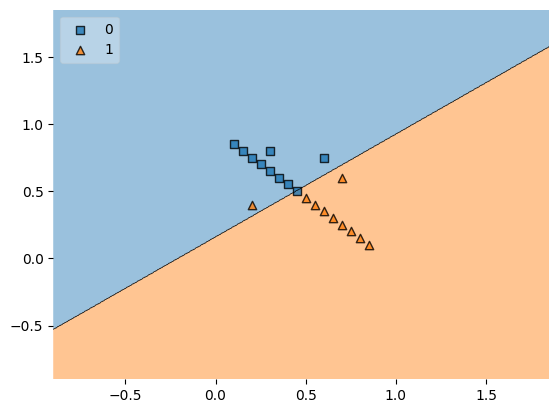

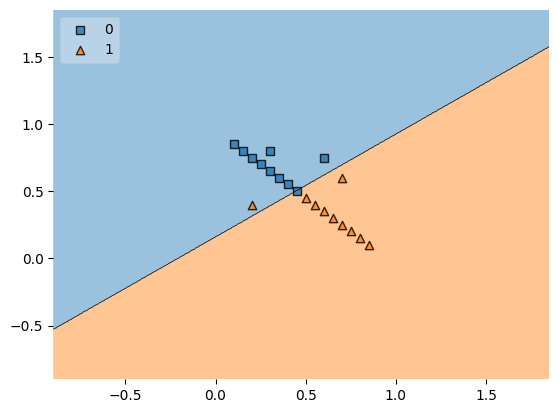

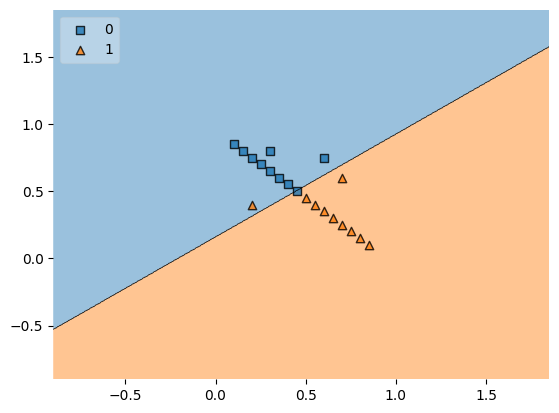

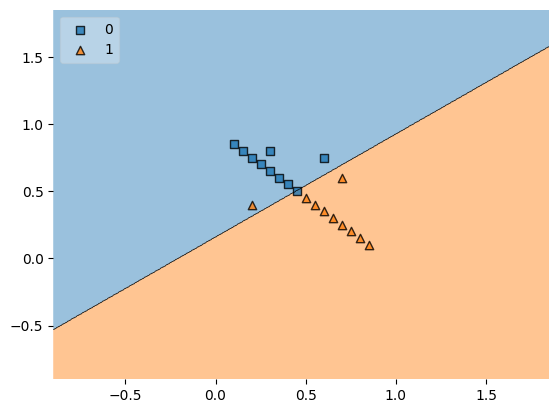

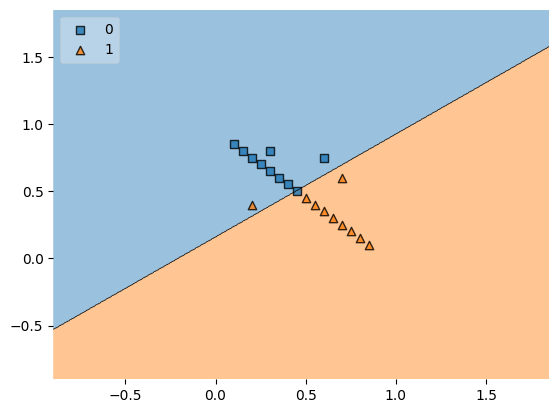

In [ ]:
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt

for i in range(5):
  P = my_Perceptron_loss(random_state=i+90)
  P.fit(X,y)
  plot_decision_regions(X.values,y.values,clf=P,legend=2)
  plt.show()